In [1]:
import sys
sys.path.append('..')

from matplotlib import pyplot as plt
from src.analysis import break_even_analysis, comparative_statics, stochastic_bivariate_simulation, run_monte_carlo, \
    run_two_way_sensitivity_analysis
from src.config import variable_names
from src.engine import evaluate_chained_models, evaluate_variable_scenario_sweep, evaluate_expected_scenario
from src.models import ProfitModel, CostOfGoodsSoldModel, RevenueModel, FreeCashFlowModel, \
    CapitalExpenditureModel, DepreciationModel, ExpenseModel, NetIncomeModel, RoiModel, TotalCostModel, \
    AdvertisingEfficiencyModel
from src.plots import render_break_even_dashboard, render_comparative_statics_dashboard, generate_heatmap_from_df, \
    generate_linear_regression_from_lists, generate_histogram_from_array
from src.variables import Orders, SellingPrice, PurchasingPrice, ItemsPerOrder, USDToRMB, Rent, TaxRate, \
    CostPerAcquisition, ConversionRate, RenderFee, TravelFee, AdvertisingCost, Expense

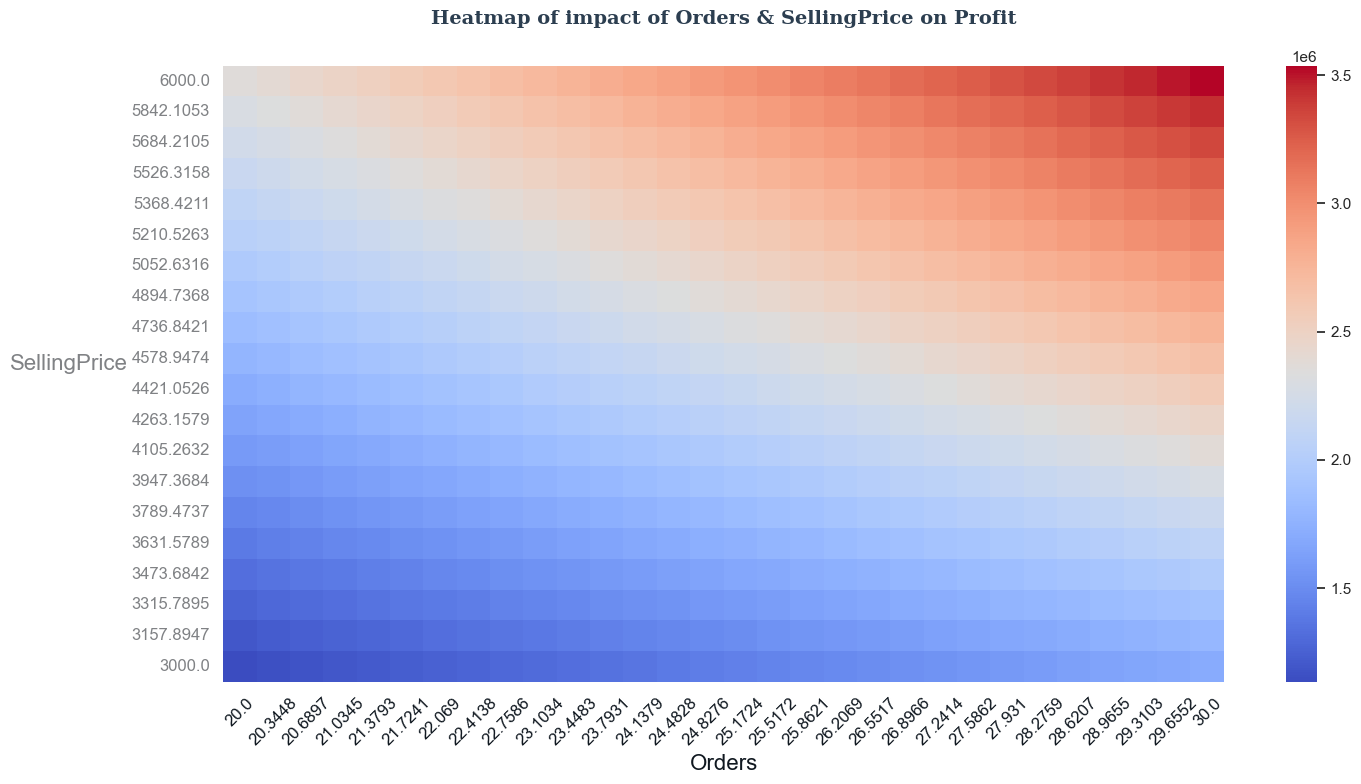

In [2]:
# advertising_budget = AdvertisingCost(min_value=10000, max_value=30000)
orders = Orders(min_value=20, max_value=30)
usd_to_rmb = USDToRMB(expected_value=6.8, min_value=6.0, max_value=7.5)
selling_price = SellingPrice(min_value=3000, max_value=6000)
items_per_order = ItemsPerOrder(min_value=1, max_value=5)
purchasing_price = PurchasingPrice(min_value=1000, max_value=2000)
# conversion_rate = ConversionRate(min_value=0.04, max_value=0.2)
# cpa = CostPerAcquisition(min_value=12, max_value=36)

variables = {variable_names.DEAL_ORDERS: orders,
       # variable_names.COST_CPA: cpa,
       # variable_names.COST_CONVERSION_RATE: conversion_rate,
       variable_names.DEAL_SELLING_PRICE: selling_price,
       variable_names.DEAL_PURCHASING_PRICE: purchasing_price,
       variable_names.FINANCE_USD_TO_RMB: usd_to_rmb,
       variable_names.DEAL_ITEMS_PER_ORDER: items_per_order}

cogs_model = CostOfGoodsSoldModel()
cost_model = TotalCostModel()
revenue_model = RevenueModel()
expense_model = ExpenseModel()
depreciation_model = DepreciationModel()
capital_expenditure_model = CapitalExpenditureModel()
net_income_model = NetIncomeModel()
# advertising_efficiency_model = AdvertisingEfficiencyModel()
# free_cash_flow_model = FreeCashFlowModel()
profit_model = ProfitModel()
# roi_model = RoiModel()

two_way_analysis_df = run_two_way_sensitivity_analysis(variables, param_x_name=variable_names.DEAL_ORDERS,
                                                       param_y_name=variable_names.DEAL_SELLING_PRICE,
                                                       model_pipeline=[cogs_model, revenue_model, cost_model,
                                                                       expense_model,
                                                                       depreciation_model, net_income_model,
                                                                       capital_expenditure_model, profit_model],
                                                       target_output_name=variable_names.PROFIT,
                                                       x_steps=30, y_steps=20)
figure = generate_heatmap_from_df(two_way_analysis_df, variable_names.PROFIT)
plt.show()